# Hiligaynon NER: Deep Error Diagnostics & Confusion Matrix

This notebook generates granular confusion matrices to expose semantic tagging boundaries. It is structured to help manually inspect and isolate misclassifications, heavily centering on the `ORG` vs `LOCATION` constraint overlap and the linguistic challenges introduced by Taglish (code-switching).

In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os
import sys
import joblib
import itertools
import tempfile
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification, PreTrainedTokenizerFast

# Ensure parent directory is in path to import from 'training' module
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

print('Diagnostic libraries loaded.')

Diagnostic libraries loaded.


In [9]:
### 0. Load Converted Verified CoNLL Data

def load_conll_data(filepath):
    """Loads sentences and BIOES/BIO tags from a CoNLL-formatted file."""
    sentences = []
    sentence_labels = []
    
    if not os.path.exists(filepath):
        print(f"Warning: CoNLL file {filepath} not found.")
        return [], []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        words, labels = [], []
        for line in f:
            line = line.strip()
            if not line or line.startswith('-DOCSTART-'):
                if words:
                    sentences.append(words)
                    sentence_labels.append(labels)
                    words, labels = [], []
            else:
                splits = line.split()
                if len(splits) >= 2:
                    words.append(splits[0])
                    labels.append(splits[-1])
        if words:
            sentences.append(words)
            sentence_labels.append(labels)
    
    return sentences, sentence_labels

# Load test, train, and validation splits from converted_verified
converted_dir = os.path.join(os.getcwd(), '..', 'data', 'converted_verified')
print(f"Loading converted CoNLL files from: {converted_dir}\n")

test_sentences, test_labels = load_conll_data(os.path.join(converted_dir, 'dataset_test_final.conll'))
train_sentences, train_labels = load_conll_data(os.path.join(converted_dir, 'dataset_train_final.conll'))
val_sentences, val_labels = load_conll_data(os.path.join(converted_dir, 'dataset_val_final.conll'))

print(f"Test set: {len(test_sentences)} sentences, {sum(len(s) for s in test_sentences)} tokens")
print(f"Train set: {len(train_sentences)} sentences, {sum(len(s) for s in train_sentences)} tokens")
print(f"Val set: {len(val_sentences)} sentences, {sum(len(s) for s in val_sentences)} tokens")
print(f"\nUnique labels in test set: {sorted(set(label for labels in test_labels for label in labels))}")

Loading converted CoNLL files from: c:\Users\Dallas\Documents\Dallas\3rd Year - 2nd Sem\Natural Lanugage Processing\FINAL PROJECT\HiliTag\evaluation\..\data\converted_verified

Test set: 647 sentences, 14365 tokens
Train set: 5203 sentences, 115021 tokens
Val set: 648 sentences, 14320 tokens

Unique labels in test set: ['B-DATETIME', 'B-EVENT', 'B-LOCATION', 'B-MONEY', 'B-NORP', 'B-ORG', 'B-PERSON', 'E-DATETIME', 'E-EVENT', 'E-LOCATION', 'E-MONEY', 'E-NORP', 'E-ORG', 'E-PERSON', 'I-DATETIME', 'I-EVENT', 'I-LOCATION', 'I-MONEY', 'I-NORP', 'I-ORG', 'I-PERSON', 'O', 'S-DATETIME', 'S-EVENT', 'S-LOCATION', 'S-MONEY', 'S-ORG', 'S-PERSON']


### 1. Generating the Heatmap

In [10]:
def plot_confusion_matrix(y_true, y_pred, classes, title='NER Confusion Matrix', cmap='Reds'):
    """Plots a seaborn heatmap of the classification confusion matrix."""
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, 
                xticklabels=classes, yticklabels=classes, 
                cbar=False, linewidths=.5)
    
    plt.ylabel('True Labels', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Labels', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Flatten test labels for analysis
y_true_flat = []
for labels in test_labels:
    y_true_flat.extend(labels)

unique_labels = sorted(set(y_true_flat))
print(f"Total test tokens: {len(y_true_flat)}")
print(f"Label distribution:")
for label in unique_labels:
    count = y_true_flat.count(label)
    pct = 100 * count / len(y_true_flat)
    print(f"  {label}: {count} ({pct:.1f}%)")

Total test tokens: 14365
Label distribution:
  B-DATETIME: 73 (0.5%)
  B-EVENT: 113 (0.8%)
  B-LOCATION: 130 (0.9%)
  B-MONEY: 27 (0.2%)
  B-NORP: 2 (0.0%)
  B-ORG: 26 (0.2%)
  B-PERSON: 211 (1.5%)
  E-DATETIME: 73 (0.5%)
  E-EVENT: 113 (0.8%)
  E-LOCATION: 130 (0.9%)
  E-MONEY: 27 (0.2%)
  E-NORP: 2 (0.0%)
  E-ORG: 26 (0.2%)
  E-PERSON: 211 (1.5%)
  I-DATETIME: 41 (0.3%)
  I-EVENT: 70 (0.5%)
  I-LOCATION: 83 (0.6%)
  I-MONEY: 16 (0.1%)
  I-NORP: 2 (0.0%)
  I-ORG: 35 (0.2%)
  I-PERSON: 168 (1.2%)
  O: 12172 (84.7%)
  S-DATETIME: 34 (0.2%)
  S-EVENT: 68 (0.5%)
  S-LOCATION: 222 (1.5%)
  S-MONEY: 16 (0.1%)
  S-ORG: 18 (0.1%)
  S-PERSON: 256 (1.8%)


Loading CRF Baseline Model...
Generating CRF Confusion Matrix...


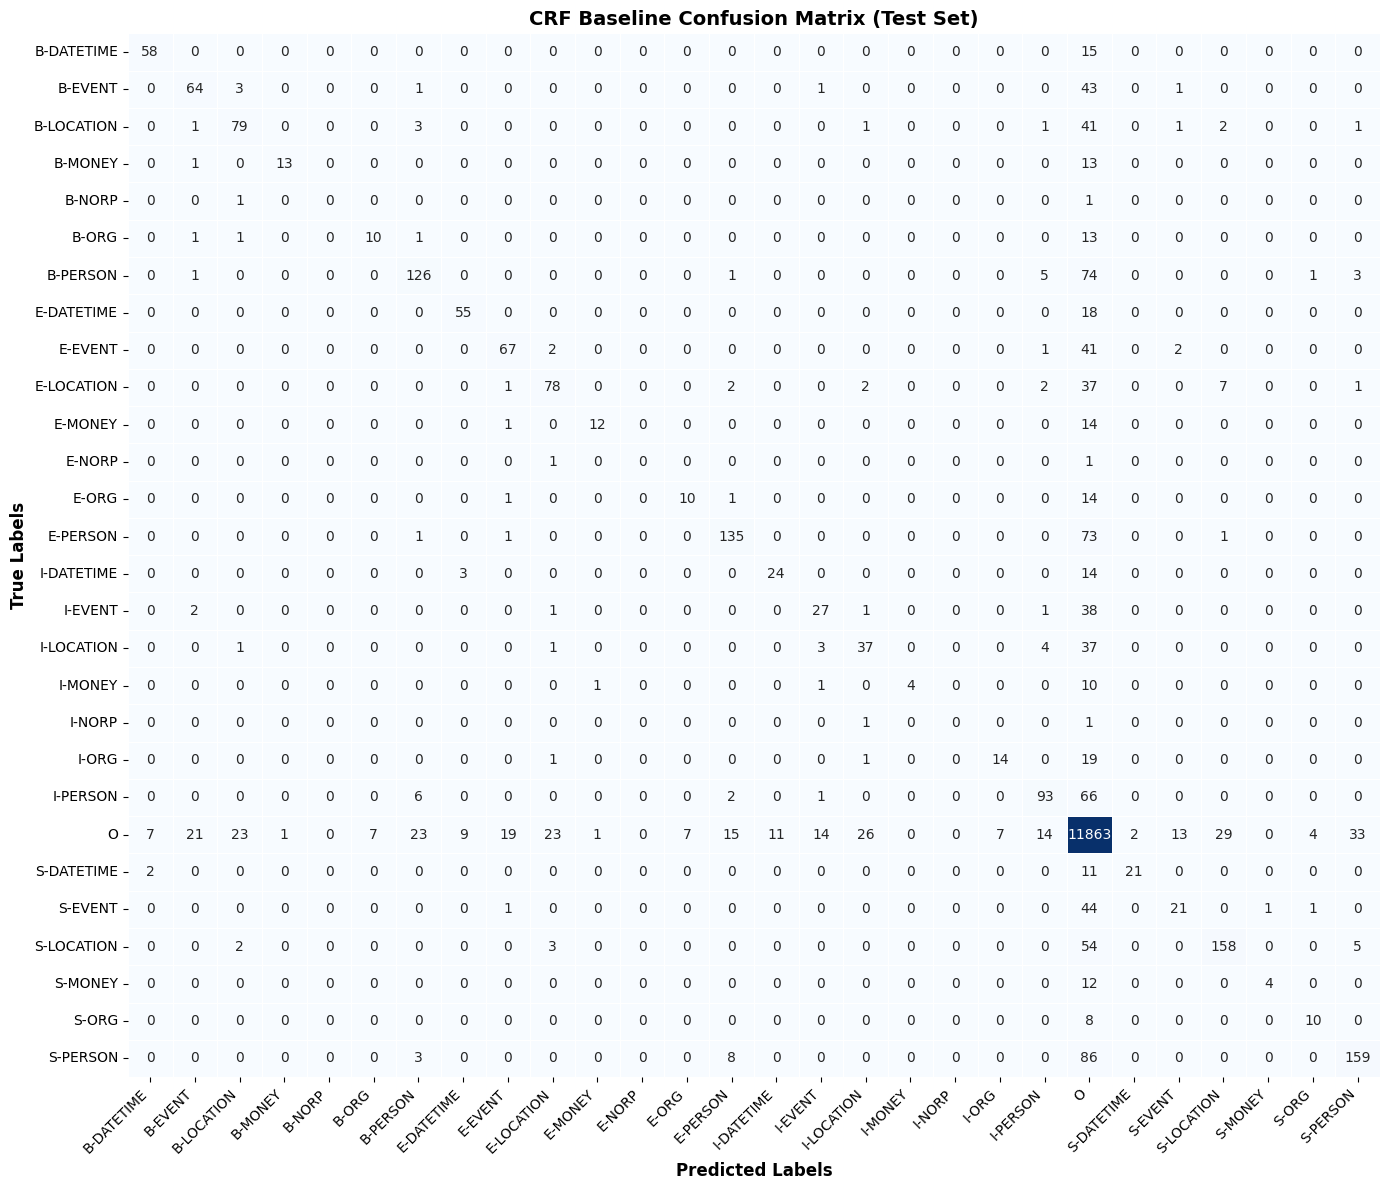

In [11]:
### 1.1 CRF Baseline Predictions & Heatmap
from training.model_crf_baseline import sent2features

crf_model_path = os.path.join('..', 'training', 'checkpoints', 'crf_baseline_model.joblib')

if os.path.exists(crf_model_path):
    print("Loading CRF Baseline Model...")
    crf = joblib.load(crf_model_path)
    
    # sent2features expects sentences where tokens are accessed via sent[i][0]
    X_test = [sent2features([[w] for w in s]) for s in test_sentences]
    y_pred_crf = crf.predict(X_test)
    
    y_pred_flat_crf = []
    for preds in y_pred_crf:
        y_pred_flat_crf.extend(preds)
        
    print("Generating CRF Confusion Matrix...")
    plot_confusion_matrix(y_true_flat, y_pred_flat_crf, unique_labels, title='CRF Baseline Confusion Matrix (Test Set)', cmap='Blues')
else:
    print(f"CRF Model not found at {crf_model_path}. Skipping CRF Heatmap.")

Loading XLM-RoBERTa Model...
Running inference on 647 test sentences...
Generating XLM-R Confusion Matrix...


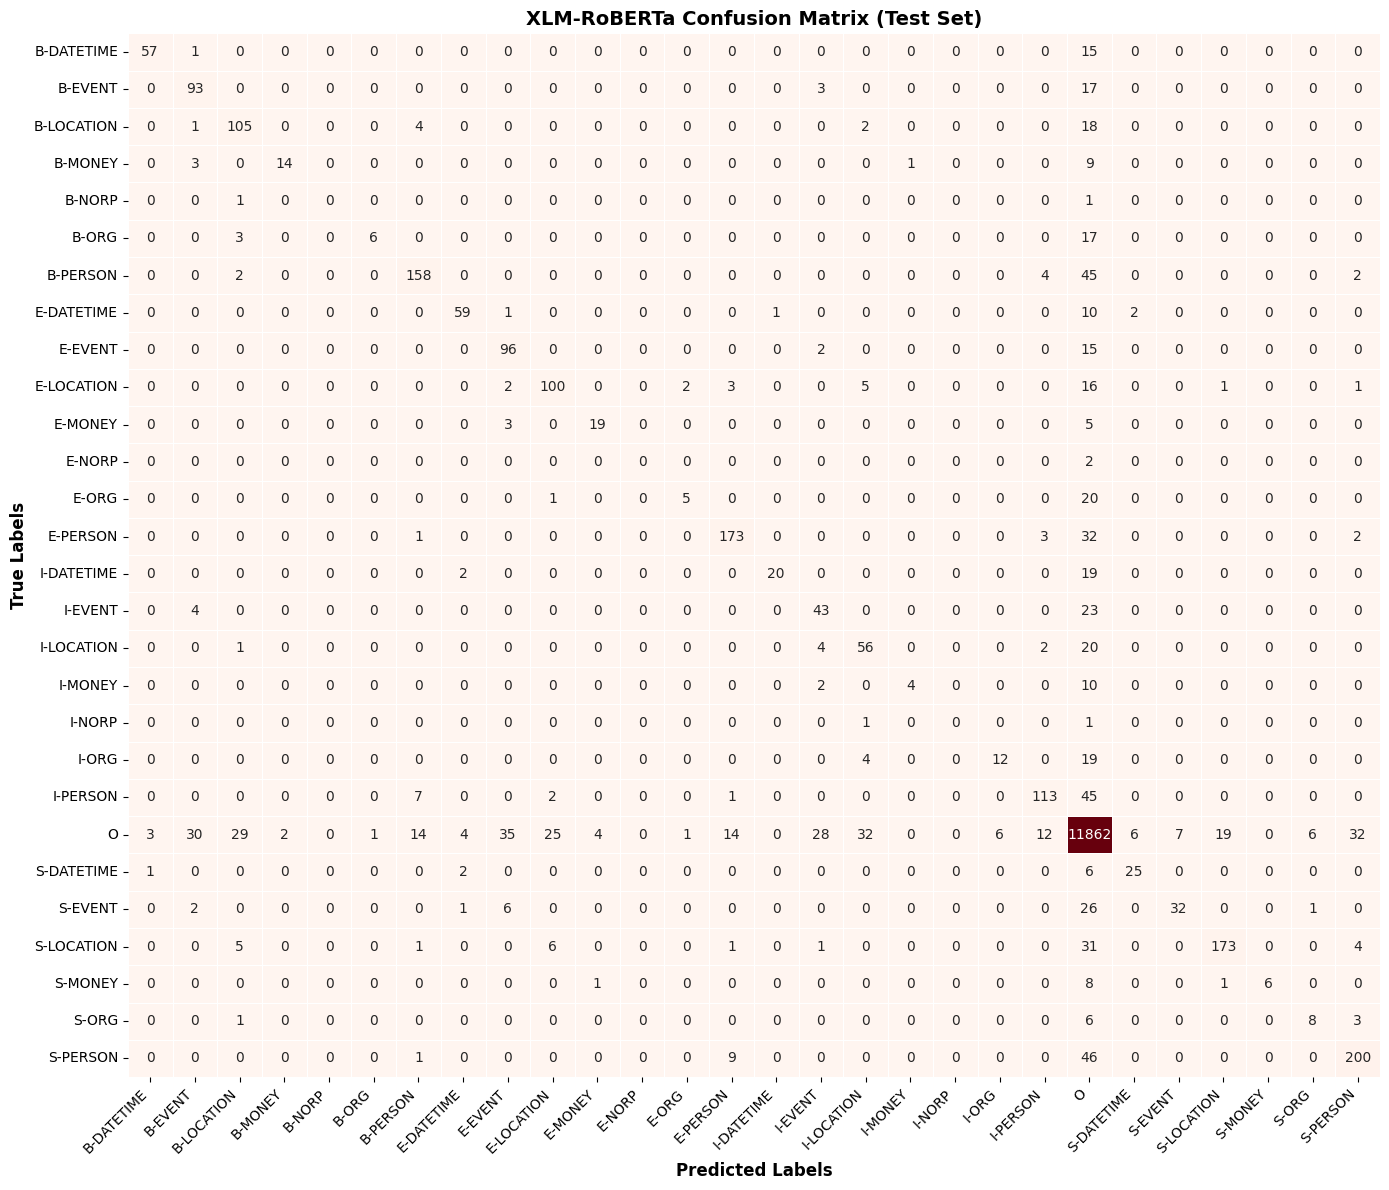

In [12]:
### 1.2 XLM-RoBERTa Predictions & Heatmap

xlm_model_path = os.path.join('..', 'training', 'checkpoints', 'best_model')

def _strip_unsupported_tokenizer_fields(value):
    """Recursively remove known cross-version tokenizer fields that can break loading."""
    if isinstance(value, dict):
        cleaned = {k: _strip_unsupported_tokenizer_fields(v) for k, v in value.items()}
        if cleaned.get("type") == "Metaspace":
            cleaned.pop("split", None)
        return cleaned

    if isinstance(value, list):
        return [_strip_unsupported_tokenizer_fields(item) for item in value]

    return value

def load_compatible_tokenizer(model_dir):
    """Load tokenizer from checkpoint with fallback for tokenizers schema drift."""
    tokenizer_config_path = os.path.join(model_dir, "tokenizer_config.json")

    try:
        return AutoTokenizer.from_pretrained(model_dir, local_files_only=True)
    except Exception as exc:
        print(f"Warning: AutoTokenizer local load failed: {exc}")

    tokenizer_path = os.path.join(model_dir, "tokenizer.json")
    if os.path.exists(tokenizer_path):
        try:
            with open(tokenizer_path, "r", encoding="utf-8") as tokenizer_file:
                tokenizer_payload = json.load(tokenizer_file)

            cleaned_payload = _strip_unsupported_tokenizer_fields(tokenizer_payload)

            special_tokens = {}
            if os.path.exists(tokenizer_config_path):
                with open(tokenizer_config_path, "r", encoding="utf-8") as cfg_file:
                    tokenizer_cfg = json.load(cfg_file)
                for key in (
                    "bos_token",
                    "eos_token",
                    "unk_token",
                    "sep_token",
                    "cls_token",
                    "pad_token",
                    "mask_token",
                ):
                    if key in tokenizer_cfg:
                        special_tokens[key] = tokenizer_cfg[key]

            with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False, encoding="utf-8") as tmp:
                json.dump(cleaned_payload, tmp, ensure_ascii=False)
                sanitized_tokenizer_path = tmp.name

            try:
                return PreTrainedTokenizerFast(tokenizer_file=sanitized_tokenizer_path, **special_tokens)
            finally:
                try:
                    os.remove(sanitized_tokenizer_path)
                except OSError:
                    pass
        except Exception as exc:
            print(f"Warning: Sanitized tokenizer load failed: {exc}")

    print("Warning: Falling back to base tokenizer: xlm-roberta-base")
    return AutoTokenizer.from_pretrained("xlm-roberta-base")

if os.path.exists(xlm_model_path):
    print("Loading XLM-RoBERTa Model...")
    tokenizer = load_compatible_tokenizer(xlm_model_path)
    model = AutoModelForTokenClassification.from_pretrained(xlm_model_path)
    nlp = pipeline("ner", model=model, tokenizer=tokenizer)
    
    y_pred_xlm = []
    print(f"Running inference on {len(test_sentences)} test sentences...")
    for idx, words in enumerate(test_sentences):
        # Reconstruct sentence text
        text = " ".join(words)
        ner_results = nlp(text)
        pred_labels = ['O'] * len(words)
        
        # Calculate character spans for original words to align predicted subwords
        word_spans = []
        curr_pos = 0
        for w in words:
            word_spans.append((curr_pos, curr_pos + len(w)))
            curr_pos += len(w) + 1
            
        for res in ner_results:
            start_char, end_char = res['start'], res['end']
            label = res['entity']
            # Map subword character offset back to the original word index
            for w_idx, (w_start, w_end) in enumerate(word_spans):
                if start_char >= w_start and start_char < w_end:
                    current_label = pred_labels[w_idx]
                    if current_label == 'O' or (current_label.startswith('I-') and label.startswith('B-')):
                        pred_labels[w_idx] = label
                    break
        y_pred_xlm.append(pred_labels)
        
    y_pred_flat_xlm = []
    for preds in y_pred_xlm:
        y_pred_flat_xlm.extend(preds)
        
    print("Generating XLM-R Confusion Matrix...")
    plot_confusion_matrix(y_true_flat, y_pred_flat_xlm, unique_labels, title='XLM-RoBERTa Confusion Matrix (Test Set)', cmap='Reds')
else:
    print(f"XLM-R Model not found at {xlm_model_path}. Skipping XLM-R Heatmap.")

### 2. Hunting Down Misclassifications (ORG vs LOCATION & Taglish)
The function below is designed to filter out exact sentences where a specific true tag is systematically predicted as a designated false tag.

In [13]:
def inspect_errors(sentences, true_labels, pred_labels, true_target='B-ORG', pred_target='B-LOCATION'):
    """
    Extracts contextual sentences where models confused true_target for pred_target.
    Used to identify systematic misclassifications (e.g., ORG vs LOCATION, Taglish code-mixing).
    """
    error_instances = []
    
    for sentence_idx, (words, t_tags, p_tags) in enumerate(zip(sentences, true_labels, pred_labels)):
        for word_idx, (word, t_tag, p_tag) in enumerate(zip(words, t_tags, p_tags)):
            if t_tag == true_target and p_tag == pred_target:
                context_start = max(0, word_idx - 2)
                context_end = min(len(words), word_idx + 3)
                context = " ".join(words[context_start:context_end])
                
                error_instances.append({
                    'sentence_idx': sentence_idx,
                    'word_idx': word_idx,
                    'word': word,
                    'context': context,
                    'true_tag': t_tag,
                    'pred_tag': p_tag
                })
    
    return error_instances

print("Error inspection functions ready.\n")

if 'y_pred_xlm' in locals():
    print("=== Analyzing XLM-RoBERTa ORG vs LOCATION Misclassifications ===")
    org_loc_errors = inspect_errors(test_sentences, test_labels, y_pred_xlm, 'B-ORG', 'B-LOCATION')
    print(f"Found {len(org_loc_errors)} instances where B-ORG was wrongly predicted as B-LOCATION.")
    for err in org_loc_errors[:10]:
        print(f"Word: '{err['word']}' | True: {err['true_tag']} -> Pred: {err['pred_tag']}")
        print(f"Context: {err['context']}\n")
elif 'y_pred_crf' in locals():
    print("=== Analyzing CRF ORG vs LOCATION Misclassifications ===")
    org_loc_errors = inspect_errors(test_sentences, test_labels, y_pred_crf, 'B-ORG', 'B-LOCATION')
    print(f"Found {len(org_loc_errors)} instances where B-ORG was wrongly predicted as B-LOCATION.")
    for err in org_loc_errors[:10]:
        print(f"Word: '{err['word']}' | True: {err['true_tag']} -> Pred: {err['pred_tag']}")
        print(f"Context: {err['context']}\n")
else:
    print("Run the model prediction cells above to populate pred_labels.")

Error inspection functions ready.

=== Analyzing XLM-RoBERTa ORG vs LOCATION Misclassifications ===
Found 3 instances where B-ORG was wrongly predicted as B-LOCATION.
Word: 'International' | True: B-ORG -> Pred: B-LOCATION
Context: gikan sa International Criminal Court

Word: 'Iloilo' | True: B-ORG -> Pred: B-LOCATION
Context: naman sang Iloilo City Government

Word: 'Manila' | True: B-ORG -> Pred: B-LOCATION
Context: Suno sa Manila International Airport



### 3. Comprehensive Performance Metrics (F1-Score Diagram)
Visualizing the F1-scores across all entity classes allows us to immediately identify which specific tags the model struggles with the most.

Plotting XLM-RoBERTa F1-Scores...


C:\Users\Dallas\AppData\Local\Temp\ipykernel_17176\1844852466.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F1-Score', y='Entity', data=df, palette='viridis')


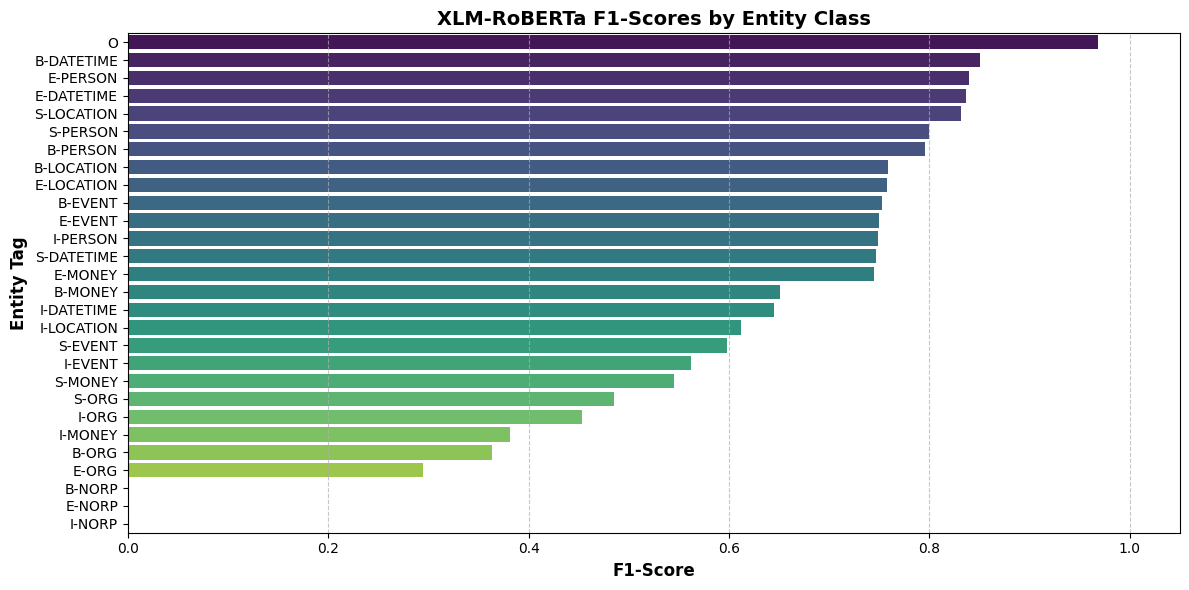

In [14]:
from sklearn.metrics import classification_report
import pandas as pd

def plot_f1_scores(y_true, y_pred, title="NER F1-Scores by Entity Class"):
    """Generates a bar chart of F1-scores for each class, ignoring 'O' if desired."""
    # Generate classification report
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    
    # Extract classes (ignoring 'accuracy', 'macro avg', 'weighted avg')
    classes = [c for c in report.keys() if c not in ['accuracy', 'macro avg', 'weighted avg']]
    
    f1_scores = [report[c]['f1-score'] for c in classes]
    
    # Create DataFrame for plotting
    df = pd.DataFrame({'Entity': classes, 'F1-Score': f1_scores})
    df = df.sort_values(by='F1-Score', ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x='F1-Score', y='Entity', data=df, palette='viridis')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('F1-Score', fontsize=12, fontweight='bold')
    plt.ylabel('Entity Tag', fontsize=12, fontweight='bold')
    plt.xlim(0, 1.05)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

if 'y_pred_flat_xlm' in locals():
    print("Plotting XLM-RoBERTa F1-Scores...")
    plot_f1_scores(y_true_flat, y_pred_flat_xlm, title="XLM-RoBERTa F1-Scores by Entity Class")
elif 'y_pred_flat_crf' in locals():
    print("Plotting CRF F1-Scores...")
    plot_f1_scores(y_true_flat, y_pred_flat_crf, title="CRF F1-Scores by Entity Class")

### 4. Normalized Confusion Matrix
Because the 'O' (Outside) tag heavily dominates token classification, rare misclassifications between minority entities (like `B-MONEY` vs `I-MONEY`) can be drowned out. A row-normalized heatmap solves this.

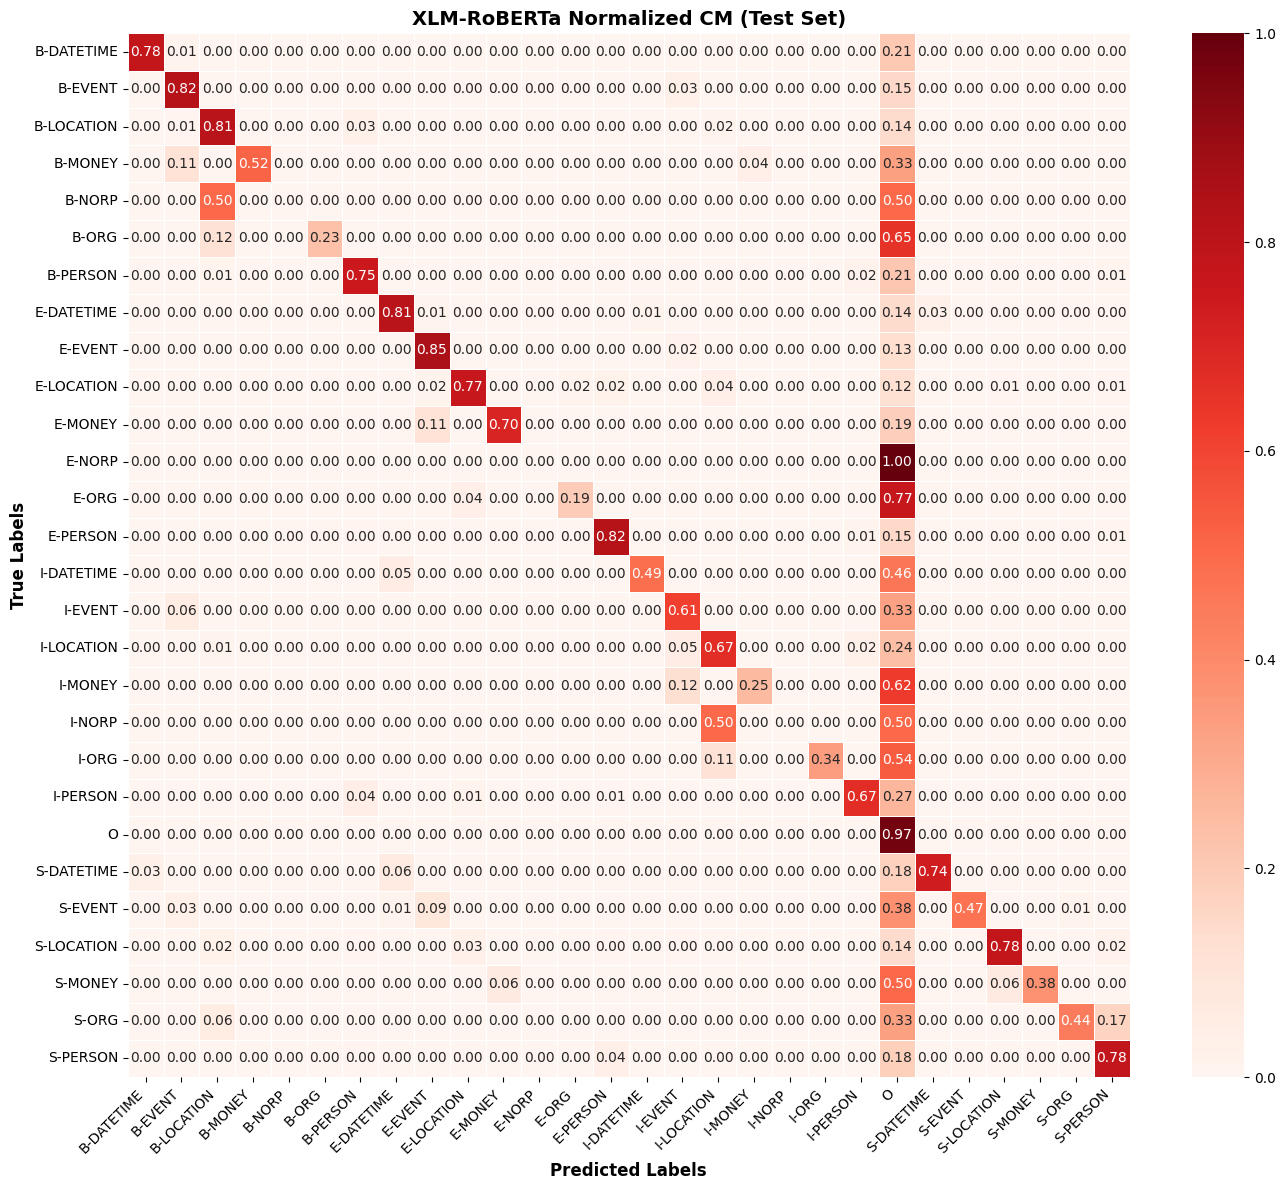

In [15]:
def plot_normalized_confusion_matrix(y_true, y_pred, classes, title='Normalized Confusion Matrix', cmap='Purples'):
    """Plots a row-normalized confusion matrix to show percentages."""
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    # Normalize across rows (True Labels)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized) # Handle division by zero
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap=cmap, 
                xticklabels=classes, yticklabels=classes, 
                cbar=True, linewidths=.5)
    
    plt.ylabel('True Labels', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Labels', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

if 'y_pred_flat_xlm' in locals():
    plot_normalized_confusion_matrix(y_true_flat, y_pred_flat_xlm, unique_labels, title='XLM-RoBERTa Normalized CM (Test Set)', cmap='Reds')
elif 'y_pred_flat_crf' in locals():
    plot_normalized_confusion_matrix(y_true_flat, y_pred_flat_crf, unique_labels, title='CRF Normalized CM (Test Set)', cmap='Blues')

### 5. Top 10 Most Frequent Misclassifications
A direct bar chart highlighting exactly where the model generates its highest volume of mistakes (excluding correct predictions).

C:\Users\Dallas\AppData\Local\Temp\ipykernel_17176\2302127534.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=labels, palette='magma')


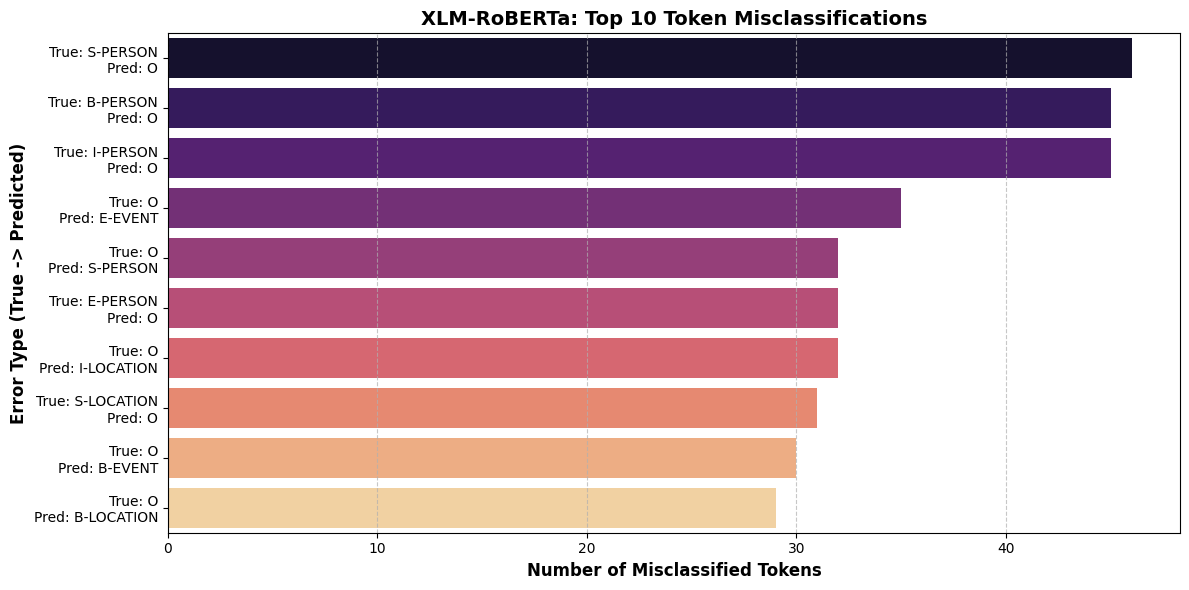

In [16]:
def plot_top_misclassifications(y_true, y_pred, top_n=10, title="Top 10 Misclassifications"):
    """Plots a bar chart of the most frequent errors made by the model."""
    # Filter out correct predictions
    errors = [(true, pred) for true, pred in zip(y_true, y_pred) if true != pred]
    
    if not errors:
        print("No misclassifications found!")
        return
        
    # Count frequencies of each specific error pair
    error_counts = {}
    for pair in errors:
        error_counts[pair] = error_counts.get(pair, 0) + 1
        
    # Sort and get top N
    sorted_errors = sorted(error_counts.items(), key=lambda x: x[1], reverse=True)[:top_n]
    
    labels = [f"True: {true}\nPred: {pred}" for (true, pred), count in sorted_errors]
    counts = [count for (true, pred), count in sorted_errors]
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=counts, y=labels, palette='magma')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Number of Misclassified Tokens', fontsize=12, fontweight='bold')
    plt.ylabel('Error Type (True -> Predicted)', fontsize=12, fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

if 'y_pred_flat_xlm' in locals():
    plot_top_misclassifications(y_true_flat, y_pred_flat_xlm, top_n=10, title="XLM-RoBERTa: Top 10 Token Misclassifications")
elif 'y_pred_flat_crf' in locals():
    plot_top_misclassifications(y_true_flat, y_pred_flat_crf, top_n=10, title="CRF: Top 10 Token Misclassifications")